In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))

32033


In [29]:
chars = list(sorted(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [151]:
block_size = 3  # context length: tells how many characters do we take to predict the next one?
X, Y = [], []

for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [152]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
# we have to create a lookup table now C 
# C is basically all the characters in the dataset (a-z and dot) with their embeddings
# initially we can randomly create C
C = torch.randn((27, 2)) # all 27 characters with each with embedding dimension 2
# like we did in the last tutorial, we can make one hot encoding vectors for each character (its index)
# suppose we create it for 4
print(F.one_hot(torch.tensor(4), num_classes=27).float() @ C)
print(C[4])
# tensor([-0.1973, -0.9270])
# tensor([-0.1973, -0.9270])
# both of these values are coming out to be indentical as one hot masks everything else and just outputs C[4]
# so we can skip the one hot vectors for these characters and consider the C[i] as the embedding of that particular character

tensor([-0.1973, -0.9270])
tensor([-0.1973, -0.9270])


In [ ]:
# we will just use C and no one hot encoding
C[[5, 6, 7]] # we can index tensor with a list or tensors of indices too
# tensor([[ 0.1391, -0.9512],
#         [-3.0933, -1.1607],
#         [-0.9058, -0.3994]])
print(C.shape)
print(X.shape)
print(C[torch.stack([X[0], X[1]])])
# pytorch lets us index in two dimensions too


torch.Size([27, 2])
torch.Size([32, 3])
tensor([[[-0.9796, -1.3225],
         [-0.9796, -1.3225],
         [-0.9796, -1.3225]],

        [[-0.9796, -1.3225],
         [-0.9796, -1.3225],
         [ 0.1391, -0.9512]]])


C's shape is 27, 2. This represents an embedding for each character. It is like a global dictionary.\
X's shape is 32, 3 (for now). That means that there are 32 inputs and each input has 3 characters.\
Now what we want is to get the embedding of each character for each input.\
That means there are 32 inputs, each input has 3 characters, and from the lookup table C, each character has embedding dimension of 2.\
So intuitively, we want an embedding matrix with a shape of 32 x 3 x 2.\
If we do C[X], we get exactly this embedding matrix

In [86]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [87]:
# now will construct the hidden layer. The non linear layer with tanh
# what would be the input size to the hidden layer?
# it would be 3 x 2 = 6. Why? Each input has 3 chars and each character has 2 dimensional embedding

W1 = torch.randn((6, 100)) # 100 neurons (variable)
b1 = torch.randn(100)

# we want to do something like emb @ W1 + b1
# but this won't work as dimension of emb is 32, 3, 2
# we want to stack up the 3 * 2 dimensions and somehow make it to 6 to make the emb 32 x 6

In [ ]:
print(emb[:, 0, :].shape)
# this represents embedding of the first character in each input
print(emb[:, 1, :].shape)
print(emb[:, 2, :].shape)

# we have to concatenate them together
torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), 1).shape
# this is not great way to do this as when the block size changes, this would be rendered useless
# for that we can use a torch function called unbind
torch.cat(torch.unbind(emb, 1), 1).shape # this is a more complete way to do it
# but we can use a more efficient way to do it by a function called torch.view

torch.Size([32, 2])
torch.Size([32, 2])
torch.Size([32, 2])


torch.Size([32, 6])

In [99]:
a = torch.arange(18)
print(a.view((9, 2)))
print(a.view((2, 9)))
print(a.view((3, 3, 2)))

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])
tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])


In [101]:
emb.view((32, 6)) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [106]:
# h = emb.view(32, 6) @ W1 + b1
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # putting -1 so as to not harcode the value and by -1 pytorch infer by itself what value needs to be there 
h

# we also converted it to 
# this works perfectly fine now

tensor([[ 0.9949, -0.3730, -0.3163,  ..., -0.5128, -0.8304, -1.0000],
        [ 0.6956, -0.9653,  0.4903,  ...,  0.0633, -0.9471, -1.0000],
        [ 0.6588, -0.9725, -0.9665,  ...,  0.8959, -0.9463, -1.0000],
        ...,
        [-0.9495, -1.0000, -0.8867,  ...,  0.9992, -1.0000,  0.6964],
        [-0.9856, -0.9883, -0.9866,  ...,  0.9992, -0.9967,  0.9973],
        [ 0.6843,  0.8421, -0.9969,  ...,  0.9979, -0.9459,  0.9979]])

In [107]:
# now for the final layer i.e. the softmax layer
W2 = torch.randn((100, 27)) # as input would be the output of the last layer and number of outputs is the final output i.e. 27
b2 = torch.randn(27)

In [108]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [111]:
# we will do softmax manually
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

In [113]:
# we want to compare these probabilities with the actual ground truth values
probs[torch.arange(32), Y] # basically 0th index is from 0 to 31 representing each input and we are taking Yth column from each to compare the ground truth probabilities

tensor([1.2627e-06, 4.8993e-11, 7.7057e-08, 7.0405e-07, 9.1464e-10, 5.0913e-07,
        2.4104e-14, 1.4723e-10, 2.2599e-10, 1.3314e-08, 8.7809e-10, 1.0065e-07,
        7.3679e-04, 8.6696e-05, 1.0319e-10, 9.5949e-07, 1.6436e-06, 1.1068e-06,
        4.0516e-04, 9.0909e-06, 1.0000e+00, 7.5155e-04, 5.5131e-08, 3.5246e-09,
        8.1699e-07, 1.8193e-04, 2.4175e-07, 1.0705e-06, 1.9480e-10, 5.9542e-05,
        9.3437e-08, 5.8547e-07])

In [115]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(15.3735)

In [153]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [156]:
# writing everything in a more respectable way
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)  # lookup table or the global dictionary
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [157]:
sum(p.nelement() for p in parameters)

3481

In [129]:
emb = C[X]  # shape: 32, 3, 2
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer, shape: 32, 100
logits = h @ W2 + b2 # shape: 32, 27
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(32), Y].log().mean()
print(loss)

tensor(17.7697)


In [ ]:
# instead of manually calculating counts and probabilities, we should F.cross_entropy() function
# Reasons:
# 1. Much more efficient forward pass and backward pass
# 2. numerically more stable.
# suppose there is number in logits that is very big like 100. Now, when exp() 100, it is very big and python gives Nan
# to deal with this, pytorch subtracts an offset to make these values more stable
logits = torch.tensor([-1, 2, 4, 3])
counts = logits.exp() # tensor([ 0.3679,  7.3891, 54.5982, 20.0855])
probs = counts / counts.sum() # tensor([0.0045, 0.0896, 0.6623, 0.2436])
print(probs)

logits = torch.tensor([-1, 2, 4, 95])
counts = logits.exp()
probs = counts / counts.sum()
print(probs) # tensor([0., 0., 0., nan])


logits = torch.tensor([-1, 2, 4, 3]) - 4
counts = logits.exp()
probs = counts / counts.sum()
print(probs) # tensor([0.0045, 0.0896, 0.6623, 0.2436])

# even after the offset, we are getting the exact same values
# so this is how pytorch internally handles these extreme values
# so always use cross_entropy function

tensor([0.0045, 0.0896, 0.6623, 0.2436])
tensor([0., 0., 0., nan])
tensor([0.0045, 0.0896, 0.6623, 0.2436])


In [158]:
emb = C[X]  # shape: 32, 3, 2
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer, shape: 32, 100
logits = h @ W2 + b2 # shape: 32, 27
loss = F.cross_entropy(logits, Y)
print(loss)

tensor(19.5052)


In [212]:
# building the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [214]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(len(words))

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])
32033


In [257]:
g = torch.Generator().manual_seed(2147483647)
# C = torch.randn((27, 2), generator=g)  # lookup table or the global dictionary
C = torch.randn((27, 10), generator=g) # scaling up the embedding size
# W1 = torch.randn((6, 100), generator=g) # increasing the complexity of the network by making the no. of neurons in the hidden layer 300 from 100
# W1 = torch.randn((6, 300), generator=g)
W1 = torch.randn((30, 200), generator=g) # as per the new embedding size
# b1 = torch.randn(100, generator=g)
b1 = torch.randn(200, generator=g)
# W2 = torch.randn((100, 27), generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [258]:
sum(p.nelement() for p in parameters)

11897

In [262]:
for p in parameters:
    p.requires_grad = True

In [183]:
# to find a good learning rate for your training, we can track learning rates
# we first check the training on the extreme learning like 0.001 and 1 or 2
# we see that 0.001, training is very slow and on 1, the loss is kind of exploding
# so we create a linspace of powers and then we exponentiate them
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre # we did this as we wanted learning rates to be in the exponent space and not in linear space

In [273]:
lrei = [] # tracking exp values
lrli = [] # to track the linear values too
lossi = []
stepi = []

In [274]:
# full training

steps = 200000
for k in range(steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(f"{k}: {loss}")
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # weight updates
    # lr = lrs[k]
    lr = 0.1 if k < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lrei.append(lr)
    # lrli.append(lre[k]) 
    stepi.append(k)
    lossi.append(loss.log10().item())

print(loss)

# minibatch is taking 32 indices at random and finding gradients on that. This is not the exact gradients but this is much faster and 
# in practice this is done more as taking more steps in the approximate gradient direction is better than taking less steps in 
# the exact gradient direction

tensor(1.8547, grad_fn=<NllLossBackward0>)


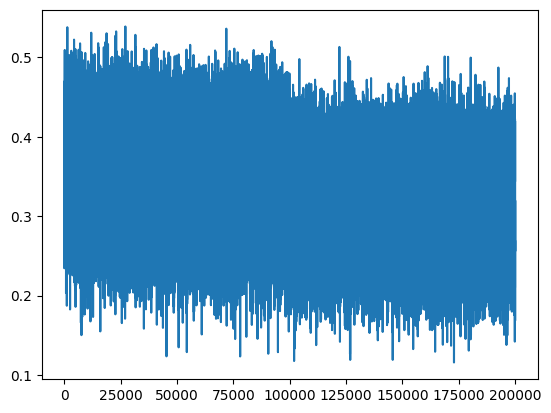

In [275]:
plt.plot(stepi, lossi)

# the noise that we can see in the loss is because of the minibatch
# the batch size is low for the minibatch. So we are not getting the correct gradient and we are thrashing a lot when are optimizing the network

In [276]:
# calculating loss on train and dev
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print("Train loss:", loss.item())

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print("Train loss:", loss.item())

# Train loss: 2.3936097621917725
# Train loss: 2.395171642303467

# wr are getting the same loss for both train and dev. That tells us that we are not overitting at all.
# In fact we are underfitting since there is still some loss.
# Our network is very tiny. We can increase the complexity of the network.

Train loss: 2.0903849601745605
Train loss: 2.145904302597046


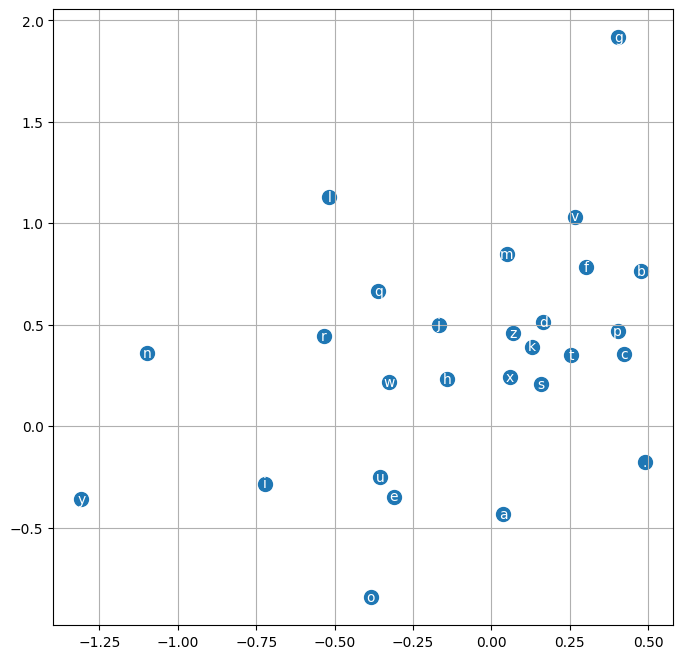

In [ ]:
# okay now are not improving the model at all. The probable bottleneck is size of the embedding in the first layer.
# We are embedding each character in just two dimensions and maybe that is very less information for the model for each character.
# let us visualize the embedding vectors
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=100)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')

plt.grid('minor')

# after the training we can see that there is some structure there as all the vowels are together.
# some letters like y is very far off.
# we will scale up the embedding size now.

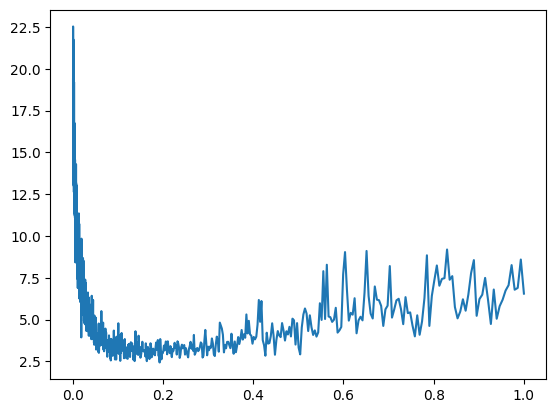

In [186]:
plt.plot(lrei, lossi)

# so, looking at the plot, we can see that initially lr is very low and so loss is reducing very slow. 
# Towards the higher learning rate, loss is becoming very unstable
# The best range for the learning rate is around at the bottom before 0.2

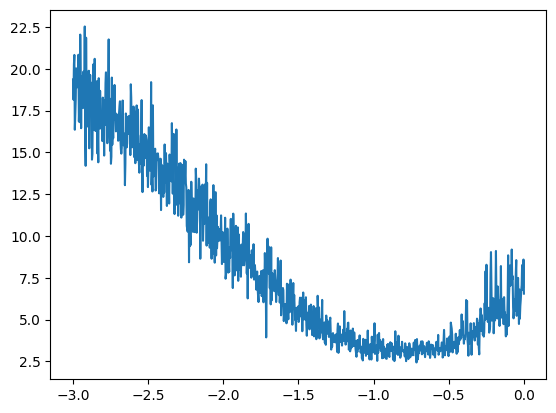

In [ ]:
plt.plot(lrli, lossi)

# checking this plot we can see that for linear value -1 and -0.5, loss is stable. So, basically 10**-1 is a good learning rate for this problem
# this is roughly how we can determine the learning rate

In [147]:
print(logits.max(1))

torch.return_types.max(
values=tensor([11.9198, 14.6964, 19.1838, 17.9729, 15.3666, 11.9198, 14.1235, 12.2951,
        13.9886, 16.5048, 13.7090, 18.6313, 11.9198, 14.8917, 15.5874, 16.8399,
        11.9198, 14.6168, 13.2689, 14.8248, 17.2716, 13.9561,  8.9987,  9.0999,
        14.2180, 11.9198, 14.6126, 14.9023, 11.8482, 14.7536, 17.2426, 14.2161],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1, 13, 13,  1,  0,  1, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  1, 19,
         1,  2,  5, 12, 12,  1,  0,  1, 15, 16,  8,  9,  1,  0]))


In [148]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [290]:
# sampling from this model
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # this is the input embedding. Now we pass this information to the hidden tanh layer
        h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, 1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    
    print(''.join(out))


    

# we will start from ... and we will end when we get .

# loss is lesser than what we got using bigrams approach and even from the names we can see that we are getting much better names
    

dex.
maleah.
makilah.
tyha.
malimitta.
malka.
kama.
dakseer.
pebraxhruvitai.
moziella.
kinzie.
dagen.
emma.
sadel.
akaviyah.
fobs.
malynn.
broahlan.
kasdra.
antil.
